In [1]:
import os
import dandelion as ddl
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns
import scanpy as sc

sc.settings.verbosity = 3

# change to tutorials directory
os.chdir("dandelion_tutorial")

In [2]:
adata = sc.read_h5ad("adata.h5ad")
adata

AnnData object with n_obs × n_vars = 25057 × 1308
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'gmm_pct_count_clusters_keep', 'scrublet_score', 'is_doublet', 'filter_rna', 'has_contig', 'productive_VDJ', 'productive_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'junction_VDJ', 'junction_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'locus_VDJ', 'locus_VJ', 'v_call_VDJ', 'v_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'umi_count_VDJ', 'umi_count_VJ', 'productive_VDJ_main', 'productive_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'junction_VDJ_main', 'junction_VJ_main', 'junction_aa_VDJ_main', 'junction_aa_VJ_main', 'locus_VDJ_main', 'locus_VJ_main', 'v_call_genotyped_VDJ_main', 'v_call_genotyped_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'umi_count_VDJ_main', 'umi_count_VJ_main', 'isotype', 'isotype_main', 'isotype_status', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_VJ', 'lei

In [3]:
vdj = ddl.read_zipddl("dandelion_results.zipddl")
vdj

Lazy Dandelion object with n_obs = 2493 and n_contigs = 5760
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, consensus_count, umi_count, v_call_10x, d_call_10x, j_call_10x, junction_10x, junction_10x_aa, j_call_blastn, j_identity_blastn, j_alignment_length_blastn, j_number_of_mismatches_blastn, j_number_of_gap_openings_blastn, j_sequence_start_blastn, j_sequence_end_blastn, j_germline_start_blastn, j_germline_end_blastn, j_support_blastn, j_score_blas

In [4]:
# let's rerun the find_clones and generate network steps again so we can visualise the data
ddl.tl.find_clones(vdj)
ddl.tl.generate_network(vdj)

Finding clonotypes
Using PyTorch backend with Apple Metal GPU


Finding clones based on B cell VDJ chains using junction_aa: 100%|██████████| 1230/1230 [00:01<00:00, 766.71it/s] 
Finding clones based on B cell VJ chains using junction_aa: 100%|██████████| 576/576 [00:00<00:00, 912.77it/s] 


Storing distance matrix...


Building distance matrix (batched): 100%|██████████| 19/19 [00:00<00:00, 3556.08it/s]

Stored distances as CSR sparse matrix: (2493, 2493), density=0.59%
 finished: Updated Dandelion object: 
   'data', contig AIRR table
   'metadata', cell observations table
   'distances', sparse distance matrix
 (0:00:03)
Generating network
Using pre-computed distances from .distances



Computing network layout


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Computing expanded network layout
 finished.
   Updated Dandelion object
:    'layout', graph layout
 (0:00:00)


In [5]:
# now let's create a large sample using vdj_sample with probability weighting based on the clone size proportions so that larger clones are more likely to be sampled
ddl.tl.clone_size(vdj)
# let's materialize the vdj object to be eager so that we can use it for sampling with probabilities
vdj.to_eager()
vdj_large = ddl.tl.vdj_sample(
    vdj_data=vdj,
    size=10000,
    p=vdj.metadata["clone_id_size_prop"],
    random_state=42,
)
vdj_large

Resampling to 10000 cells.


Lazy Dandelion object with n_obs = 10000 and n_contigs = 16228
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, consensus_count, umi_count, v_call_10x, d_call_10x, j_call_10x, junction_10x, junction_10x_aa, j_call_blastn, j_identity_blastn, j_alignment_length_blastn, j_number_of_mismatches_blastn, j_number_of_gap_openings_blastn, j_sequence_start_blastn, j_sequence_end_blastn, j_germline_start_blastn, j_germline_end_blastn, j_support_blastn, j_score_bl

In [6]:
from Bio.Seq import Seq
import random

NUCLEOTIDES = ["A", "T", "C", "G"]
GAP_CHARS = {".", "-", "N"}


def mutate_sequence(seq, mutation_rate=0.01):
    """Randomly mutate nucleotide sequence but skip gap characters."""
    seq_list = list(seq)

    for i, nt in enumerate(seq_list):
        # Skip gaps or unknown characters
        if nt.upper() not in NUCLEOTIDES:
            continue

        if random.random() < mutation_rate:
            seq_list[i] = random.choice(
                [n for n in NUCLEOTIDES if n != nt.upper()]
            )

    return "".join(seq_list)


def translate_cleaned_nt(seq):
    """Remove gap characters and translate clean nucleotide sequence."""
    cleaned = "".join([nt for nt in seq if nt.upper() in NUCLEOTIDES])
    return str(Seq(cleaned).translate(to_stop=False))


def mutate_dataframe(df, nt_col="junction", mutation_rate=0.01):
    """Mutate nucleotide sequences in the polars DataFrame and update amino acids."""
    aa_col = nt_col + "_aa"

    return df.with_columns(
        pl.col(nt_col)
        .map_elements(
            lambda seq: mutate_sequence(seq, mutation_rate),
            return_dtype=pl.Utf8,
        )
        .alias(nt_col),
    ).with_columns(
        pl.col(nt_col)
        .map_elements(translate_cleaned_nt, return_dtype=pl.Utf8)
        .alias(aa_col),
    )

In [7]:
# convert to eager again
vdj_large.to_eager()
mut_df = mutate_dataframe(
    vdj_large.data, nt_col="sequence_alignment", mutation_rate=0.01
)
vdj_large = ddl.Dandelion(mut_df)
vdj_large

/opt/homebrew/Caskroom/miniforge/base/envs/dandelion/lib/python3.12/site-packages/Bio/Seq.py:2877: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.


Lazy Dandelion object with n_obs = 10000 and n_contigs = 16228
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, consensus_count, umi_count, v_call_10x, d_call_10x, j_call_10x, junction_10x, junction_10x_aa, j_call_blastn, j_identity_blastn, j_alignment_length_blastn, j_number_of_mismatches_blastn, j_number_of_gap_openings_blastn, j_sequence_start_blastn, j_sequence_end_blastn, j_germline_start_blastn, j_germline_end_blastn, j_support_blastn, j_score_bl

In [8]:
# let's make an adata_large object with the same cells as vdj_large but with the same gene expression data as adata for easier comparison
adata_large = sc.AnnData(
    obs=vdj_large.metadata.collect().to_pandas().set_index("cell_id")
)
adata_large

AnnData object with n_obs × n_vars = 10000 × 0
    obs: 'clone_id', 'clone_id_rank', 'sample_id', 'productive_VDJ', 'productive_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'junction_VDJ', 'junction_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'locus_VDJ', 'locus_VJ', 'v_call_VDJ', 'v_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'umi_count_VDJ', 'umi_count_VJ', 'productive_VDJ_main', 'productive_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'junction_VDJ_main', 'junction_VJ_main', 'junction_aa_VDJ_main', 'junction_aa_VJ_main', 'locus_VDJ_main', 'locus_VJ_main', 'v_call_genotyped_VDJ_main', 'v_call_genotyped_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'umi_count_VDJ_main', 'umi_count_VJ_main', 'isotype', 'isotype_main', 'isotype_status', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_VJ'

Generating network
Calculating distance matrix  with distance_mode = 'clone'



100%|██████████| 2070/2070 [02:10<00:00, 15.82it/s]


Distances calculated in 131.12 seconds
Computing network layout
Computing expanded network layout
 finished.
   Updated Dandelion object
:    'layout', graph layout
 (0:02:27)
Transferring network
 finished: updated `.obs` with `.metadata`
wrote active layout to `.obsm['X_vdj']`; stashed all views in `.uns['dandelion']` ('X_vdj_all', 'X_vdj_expanded')
wrote `.obsp['connectivities']` & `['distances']` from graph[0]
stashed VDJ matrices in `.uns['dandelion']` under 'vdj_connectivities_all' / '_expanded'
added `.uns['clone_id']` clone-level mapping (0:00:00)


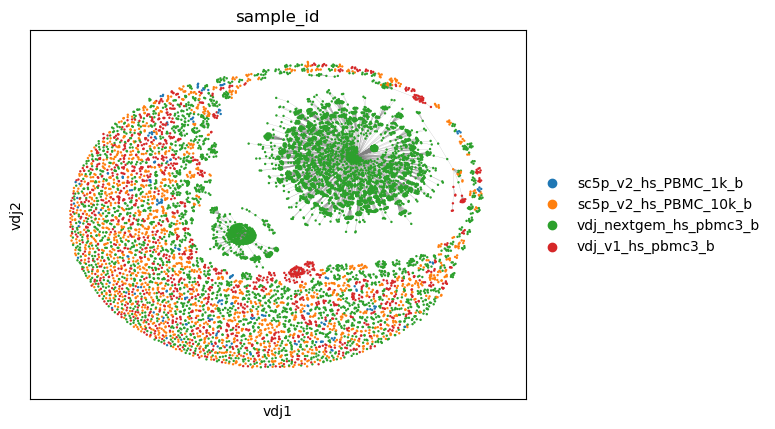

In [9]:
# what does this dataset look like?
ddl.tl.generate_network(vdj_large, use_existing_graph=False)
ddl.tl.transfer(adata_large, vdj_large)
ddl.pl.clone_network(adata_large, color=["sample_id"])

In [15]:
import networkx as nx
import numpy as np
import pandas as pd
from typing import Hashable


def _distance_to_similarity(distance: float, eps: float = 1e-9) -> float:
    """Convert distance-like edge weights to similarity-like weights."""
    return 1.0 / (float(distance) + eps)


def _with_similarity_weights(
    G: nx.Graph,
    distance_key: str = "weight",
    similarity_key: str = "similarity_weight",
) -> nx.Graph:
    """Copy graph and add similarity edge weights derived from distance weights."""
    H = G.copy()
    for _, _, data in H.edges(data=True):
        distance = data.get(distance_key, 1.0)
        try:
            data[similarity_key] = _distance_to_similarity(distance)
        except (TypeError, ValueError):
            data[similarity_key] = _distance_to_similarity(1.0)
    return H


def _largest_connected_component(G: nx.Graph) -> nx.Graph:
    """Return largest connected component as an independent graph copy."""
    if G.number_of_nodes() == 0:
        return G.copy()
    if nx.is_connected(G):
        return G.copy()
    largest_nodes = max(nx.connected_components(G), key=len)
    return G.subgraph(largest_nodes).copy()


def _sample_pairwise_distance_summary(
    G: nx.Graph,
    distance_key: str = "weight",
    n_sources: int = 32,
    random_state: int = 42,
) -> tuple[float, float, dict[Hashable, dict[Hashable, float]]]:
    """Estimate average shortest path and diameter from sampled sources."""
    if G.number_of_nodes() <= 1:
        return 0.0, 0.0, {n: {n: 0.0} for n in G.nodes()}

    rng = np.random.default_rng(random_state)
    nodes = list(G.nodes())
    n_pick = min(n_sources, len(nodes))
    source_nodes = rng.choice(nodes, size=n_pick, replace=False).tolist()

    lengths: dict[Hashable, dict[Hashable, float]] = {}
    dists: list[float] = []
    for src in source_nodes:
        src_lengths = nx.single_source_dijkstra_path_length(
            G, src, weight=distance_key
        )
        lengths[src] = src_lengths
        for dst, dist in src_lengths.items():
            if dst != src:
                dists.append(float(dist))

    diameter_est = float(max(dists)) if dists else 0.0
    avg_shortest_path_est = float(np.mean(dists)) if dists else 0.0
    return diameter_est, avg_shortest_path_est, lengths


def _exact_pairwise_distance_summary(
    G: nx.Graph, distance_key: str = "weight"
) -> tuple[float, float, dict[Hashable, dict[Hashable, float]]]:
    """Compute exact diameter and average shortest path from all pairs."""
    if G.number_of_nodes() <= 1:
        return 0.0, 0.0, {n: {n: 0.0} for n in G.nodes()}

    lengths = dict(nx.all_pairs_dijkstra_path_length(G, weight=distance_key))
    nodes = list(lengths.keys())
    dists: list[float] = []
    for i, u in enumerate(nodes):
        for v in nodes[i + 1 :]:
            dists.append(lengths[u][v])

    diameter = float(max(dists)) if dists else 0.0
    avg_shortest_path = float(np.mean(dists)) if dists else 0.0
    return diameter, avg_shortest_path, lengths


def _greedy_community_summary(
    G: nx.Graph, similarity_key: str = "similarity_weight"
) -> tuple[int, float, float]:
    """Compute greedy-modularity community summaries.

    Parameters
    ----------
    G : nx.Graph
        Input graph.
    similarity_key : str
        Edge attribute used as similarity weight for community detection and
        modularity scoring.

    Returns
    -------
    tuple[int, float, float]
        Tuple with values:

        n_communities : int
            Number of detected communities.
        modularity : float
            Partition quality score; larger values indicate stronger separation.
        largest_community_fraction : float
            Fraction of nodes in the largest detected community.
    """
    if G.number_of_nodes() <= 1:
        return 1, 0.0, 1.0

    communities = list(
        nx.algorithms.community.greedy_modularity_communities(
            G, weight=similarity_key
        )
    )
    if not communities:
        return 0, np.nan, np.nan

    modularity = nx.algorithms.community.modularity(
        G, communities, weight=similarity_key
    )
    largest_comm_size = max((len(c) for c in communities), default=0)
    largest_comm_fraction = float(largest_comm_size / G.number_of_nodes())
    return int(len(communities)), float(modularity), largest_comm_fraction


def _intraclonal_diversity_metrics(
    G: nx.Graph,
    distance_key: str = "weight",
    similarity_key: str = "similarity_weight",
    fast: bool = True,
    n_sources: int = 32,
    betweenness_k: int = 64,
    random_state: int = 42,
) -> dict[str, int | float | str]:
    """Compute clone-level intraclonal graph and community metrics.

    Parameters
    ----------
    G : nx.Graph
        Clone graph where nodes are cells/sequences and edges encode relatedness.
    distance_key : str
        Edge attribute interpreted as distance for shortest-path and centrality computations.
    similarity_key : str
        Edge attribute interpreted as similarity for PageRank and community weighting.
    fast : bool
        If True, estimate path metrics and use approximate betweenness for speed.
    n_sources : int
        Number of sampled source nodes for shortest-path estimates in fast mode.
    betweenness_k : int
        Number of sampled pivot nodes for approximate betweenness in fast mode.
    random_state : int
        Seed for reproducible sampling in fast mode.

    Returns
    -------
    dict
        Dictionary with keys (all values are int or float unless noted):

        n_nodes : int
            Number of nodes in the clone graph.
        n_edges : int
            Number of edges in the clone graph.
        largest_community_fraction : float
            Fraction of nodes in the largest greedy-modularity community. Higher values
            indicate one dominant sub-community; lower values indicate a more even split.
        n_communities_greedy : int
            Number of communities detected by greedy modularity.
        modularity_greedy : float
            Community-separation score for the detected partition. Larger values suggest
            stronger within-community connectivity relative to between-community mixing.
        density : float
            Fraction of possible edges that are present.
        mean_degree : float
            Mean node degree; reflects average connectivity level.
        var_degree : float
            Variance of node degree; reflects connectivity heterogeneity.
        degree_assortativity : float
            Degree-degree correlation across edges. Negative values suggest hub-spoke structure.
        transitivity : float
            Transitivity (global clustering coefficient). Higher values indicate tighter triangles.
        average_clustering : float
            Average clustering coefficient. Higher values suggest tighter local neighborhoods.
        diameter_component : float
            Longest shortest path in the largest detected community.
        average_shortest_path_component : float
            Mean shortest-path distance in the largest detected community.
        mean_betweenness : float
            Mean betweenness centrality in the largest detected community.
        mean_closeness : float
            Mean closeness centrality in the largest detected community.
        max_pagerank : float
            Highest PageRank score in the largest detected community.
        mode : str
            "fast" for sampled/approximate calculations or "exact" for full calculations.
    """
    if G.number_of_nodes() == 0:
        return {
            "n_nodes": 0,
            "n_edges": 0,
            "largest_community_fraction": np.nan,
            "n_communities_greedy": np.nan,
            "modularity_greedy": np.nan,
            "density": np.nan,
            "mean_degree": np.nan,
            "var_degree": np.nan,
            "degree_assortativity": np.nan,
            "transitivity": np.nan,
            "average_clustering": np.nan,
            "diameter_component": np.nan,
            "average_shortest_path_component": np.nan,
            "mean_betweenness": np.nan,
            "mean_closeness": np.nan,
            "max_pagerank": np.nan,
            "mode": "fast" if fast else "exact",
        }

    H = _with_similarity_weights(
        G, distance_key=distance_key, similarity_key=similarity_key
    )
    degrees = np.array([d for _, d in H.degree()], dtype=float)

    # Compute communities and get largest community subgraph
    n_communities, modularity, largest_community_fraction = (
        _greedy_community_summary(H, similarity_key=similarity_key)
    )

    communities = list(
        nx.algorithms.community.greedy_modularity_communities(
            H, weight=similarity_key
        )
    )

    if communities:
        largest_community_nodes = max(communities, key=len)
        H_main = H.subgraph(largest_community_nodes).copy()
    else:
        H_main = _largest_connected_component(H)

    if fast:
        diameter, avg_shortest_path, sampled_lengths = (
            _sample_pairwise_distance_summary(
                H_main,
                distance_key=distance_key,
                n_sources=n_sources,
                random_state=random_state,
            )
        )
        k = min(max(2, betweenness_k), H_main.number_of_nodes())
        betweenness = nx.betweenness_centrality(
            H_main, weight=distance_key, k=k, seed=random_state
        )
        closeness_vals = [
            nx.closeness_centrality(H_main, u=node, distance=distance_key)
            for node in sampled_lengths.keys()
        ]
    else:
        diameter, avg_shortest_path, _ = _exact_pairwise_distance_summary(
            H_main, distance_key=distance_key
        )
        betweenness = nx.betweenness_centrality(H_main, weight=distance_key)
        closeness_vals = list(
            nx.closeness_centrality(H_main, distance=distance_key).values()
        )

    pagerank = nx.pagerank(H_main, weight=similarity_key)

    return {
        "n_nodes": int(H.number_of_nodes()),
        "n_edges": int(H.number_of_edges()),
        "largest_community_fraction": float(largest_community_fraction),
        "n_communities_greedy": int(n_communities),
        "modularity_greedy": float(modularity),
        "density": float(nx.density(H)),
        "mean_degree": float(np.mean(degrees)),
        "var_degree": float(np.var(degrees)),
        "degree_assortativity": float(nx.degree_assortativity_coefficient(H)),
        "transitivity": float(nx.transitivity(H)),
        "average_clustering": float(nx.average_clustering(H)),
        "diameter_component": float(diameter),
        "average_shortest_path_component": float(avg_shortest_path),
        "mean_betweenness": float(np.mean(list(betweenness.values()))),
        "mean_closeness": (
            float(np.mean(closeness_vals)) if closeness_vals else np.nan
        ),
        "max_pagerank": float(np.max(list(pagerank.values()))),
        "mode": "fast" if fast else "exact",
    }


# Demo: compute clone-level metrics for dominant clonotype graph.
graph_obj = vdj_large.graph[1]

if isinstance(graph_obj, dict):
    clone_sizes = (
        vdj_large.data.group_by("clone_id").len().sort("len", descending=True)
    )
    dominant_clone_id = clone_sizes.get_column("clone_id")[0]
    G_dominant = graph_obj[dominant_clone_id]
    print(f"Dominant clone_id: {dominant_clone_id}")
else:
    G_dominant = graph_obj
    print("graph[1] is not clone-indexed dict; using graph[1] directly")

clone_metrics = _intraclonal_diversity_metrics(
    G_dominant, fast=True, n_sources=32, betweenness_k=64
)

display(pd.Series(clone_metrics).sort_index())

graph[1] is not clone-indexed dict; using graph[1] directly


average_clustering                    0.050033
average_shortest_path_component      10.934621
degree_assortativity                  0.618718
density                               0.001381
diameter_component                        26.0
largest_community_fraction            0.055662
max_pagerank                          0.289156
mean_betweenness                      0.002579
mean_closeness                        0.096876
mean_degree                          12.944978
mode                                      fast
modularity_greedy                     0.014673
n_communities_greedy                      1894
n_edges                                  60699
n_nodes                                   9378
transitivity                          0.974434
var_degree                         3601.978845
dtype: object

In [ ]:
def _split_clone_ids(clone_value: object) -> list[str]:
    """Split a possibly multi-assigned clone_id string into separate clone identifiers."""
    if clone_value is None or pd.isna(clone_value):
        return []
    return [
        part.strip() for part in str(clone_value).split("|") if part.strip()
    ]


def _expanded_clone_assignments(
    vdj_obj: object, clone_col: str = "clone_id", cell_col: str = "cell_id"
) -> pd.DataFrame:
    """Return one row per cell-clone assignment with smart splitting of pipe-delimited IDs.

    Splitting rule:
    - For labels like A|B, split into A and B only if at least one component (A or B)
      is observed in more than one distinct original clone label across the dataset.
    - If none of the components are reused elsewhere, keep the original combined label A|B.
    """
    node_clone_df = (
        vdj_obj.data.select([cell_col, clone_col])
        .unique(subset=[cell_col], keep="first")
        .collect()
        .to_pandas()
    )
    node_clone_df["original_clone_id"] = node_clone_df[clone_col]
    node_clone_df["parts"] = node_clone_df[clone_col].map(_split_clone_ids)

    # Map each atomic clone part to the set of original labels it appears in.
    part_to_original_ids: dict[str, set[str]] = {}
    for _, row in node_clone_df.iterrows():
        original_id = str(row["original_clone_id"])
        for part in set(row["parts"]):
            if part not in part_to_original_ids:
                part_to_original_ids[part] = set()
            part_to_original_ids[part].add(original_id)

    def _smart_assign(parts: list[str], original_id: object) -> list[str]:
        if len(parts) <= 1:
            return parts
        shared_with_others = any(
            len(part_to_original_ids.get(part, set())) > 1 for part in parts
        )
        if shared_with_others:
            return parts
        return [str(original_id)]

    node_clone_df[clone_col] = node_clone_df.apply(
        lambda row: _smart_assign(row["parts"], row["original_clone_id"]),
        axis=1,
    )
    node_clone_df = node_clone_df.explode(clone_col)
    node_clone_df = node_clone_df.dropna(subset=[clone_col])
    node_clone_df = node_clone_df.drop(columns=["parts"])
    return node_clone_df


def intraclonal_diversity(
    vdj_obj: object,
    clone_col: str = "clone_id",
    cell_col: str = "cell_id",
    min_cells: int = 20,
    top_n: int | None = 25,
    fast: bool = True,
    n_sources: int = 16,
    betweenness_k: int = 32,
    random_state: int = 42,
) -> pd.DataFrame:
    """Compute one intraclonal-diversity row per clonotype.

    Smart handling of combined clone labels containing '|':
    - Split and tabulate separately only when at least one component is reused
      in another original clone label (interpreted as genuine sharing).
    - Otherwise keep the original combined label unchanged.

    Parameters
    ----------
    vdj_obj : object
        Dandelion object containing sequence metadata in vdj_obj.data and graphs in vdj_obj.graph.
    clone_col : str
        Column with clone assignments.
    cell_col : str
        Column with node identifiers used in the graph.
    min_cells : int
        Minimum number of unique cells required to keep a clone.
    top_n : int | None
        Keep only the top N largest clones after filtering when provided.
    fast : bool
        If True, estimate path metrics and use approximate betweenness for speed.
    n_sources : int
        Number of sampled source nodes for shortest-path estimates in fast mode.
    betweenness_k : int
        Number of sampled pivot nodes for approximate betweenness in fast mode.
    random_state : int
        Seed for reproducible sampling in fast mode.

    Returns
    -------
    pd.DataFrame
        One row per reported clone with clone identifier, clone size, and all
        intraclonal diversity metrics returned by the helper:

        clone_id : str
            Reported clonotype label after smart split logic.
        clone_size : int
            Number of unique cells assigned to the reported clonotype.
        n_nodes : int
            Number of cells in the clonotype subgraph (typically equals clone_size).
        n_edges : int
            Number of observed relationships among cells in the clonotype.
        largest_community_fraction : float
            Fraction of clonotype cells in the largest subgroup. High values mean most
            cells sit in one main subgroup; low values mean the clone is split into several parts.
        n_communities_greedy : int
            Number of detected subgroups inside the clonotype. More subgroups usually
            means more internal heterogeneity.
        modularity_greedy : float
            How clearly the clonotype separates into subgroups. Higher values mean
            subgroup boundaries are stronger.
        density : float
            Fraction of all possible within-clonotype links that are present.
            Higher values indicate a more tightly interconnected clonotype.
        mean_degree : float
            Average number of within-clonotype neighbors per cell.
        var_degree : float
            How uneven connectivity is across cells. High values mean a mix of
            highly connected cells and sparsely connected cells.
        degree_assortativity : float
            Whether highly connected cells mostly link to other highly connected cells.
            Negative values mean a "core-and-branches" pattern (few central cells linked
            to many less-connected cells). Positive values mean cells tend to connect to
            others with similar connectivity.
        transitivity : float
            How often connected triplets of clonotype cells form closed triangles.
            Higher values suggest tighter local groupings.
        average_clustering : float
            Average local cohesiveness around each cell. Higher values indicate cells tend
            to form tight local neighborhoods.
        diameter_component : float
            Largest shortest-path distance within the clonotype's main subgroup.
            Higher values suggest broader spread of the lineage in sequence space.
        average_shortest_path_component : float
            Average shortest-path distance within the clonotype's main subgroup.
            Lower values indicate a more compact lineage.
        mean_betweenness : float
            Average tendency of cells to sit on paths connecting other cells.
            Higher values suggest more bridge-like cells between subgroup regions.
        mean_closeness : float
            Average proximity of cells to the rest of the main subgroup.
            Higher values indicate cells are, on average, closer to one another.
        max_pagerank : float
            Highest centrality score in the main subgroup. High values indicate one or a few
            especially influential/central cells in that clonotype structure.
        mode : str
            "fast" for sampled/approximate calculations or "exact" for full calculations.

    Notes
    -----
    Rows are sorted by clone_size (descending), then
    average_shortest_path_component (descending).
    """
    graph_obj = vdj_obj.graph[1]

    node_clone_df = _expanded_clone_assignments(
        vdj_obj, clone_col=clone_col, cell_col=cell_col
    )
    clone_sizes_pd = (
        node_clone_df.groupby(clone_col)[cell_col]
        .nunique()
        .rename("clone_size")
        .reset_index()
        .sort_values("clone_size", ascending=False)
    )
    clone_sizes_pd = clone_sizes_pd[clone_sizes_pd["clone_size"] >= min_cells]
    if top_n is not None:
        clone_sizes_pd = clone_sizes_pd.head(top_n)

    if clone_sizes_pd.empty:
        return pd.DataFrame()

    clone_to_nodes = (
        node_clone_df.groupby(clone_col)[cell_col]
        .apply(lambda x: sorted(set(x)))
        .to_dict()
    )
    clone_to_original_ids = (
        node_clone_df.groupby(clone_col)["original_clone_id"]
        .apply(lambda x: sorted(set(x)))
        .to_dict()
    )

    metrics_rows: list[dict[str, int | float | str]] = []

    for _, row in clone_sizes_pd.iterrows():
        clone_id = row[clone_col]
        clone_nodes = clone_to_nodes.get(clone_id, [])
        if not clone_nodes:
            continue

        if isinstance(graph_obj, dict):
            original_clone_ids = clone_to_original_ids.get(clone_id, [])
            candidate_graphs = [
                graph_obj[original_id]
                for original_id in original_clone_ids
                if original_id in graph_obj
            ]
            if not candidate_graphs:
                continue
            G_source = nx.compose_all(candidate_graphs)
        else:
            G_source = graph_obj

        G_clone = G_source.subgraph(clone_nodes).copy()
        if G_clone.number_of_nodes() == 0:
            continue

        metrics = _intraclonal_diversity_metrics(
            G_clone,
            fast=fast,
            n_sources=n_sources,
            betweenness_k=betweenness_k,
            random_state=random_state,
        )
        metrics[clone_col] = str(clone_id)
        metrics["clone_size"] = int(row["clone_size"])
        metrics_rows.append(metrics)

    if not metrics_rows:
        return pd.DataFrame()

    out = pd.DataFrame(metrics_rows)

    # Keep clone identifiers first for consistent user-facing layout.
    first_cols = [clone_col, "clone_size"]
    remaining_cols = [c for c in out.columns if c not in set(first_cols)]
    out = out[first_cols + remaining_cols]

    out = out.sort_values(
        ["clone_size", "average_shortest_path_component"],
        ascending=[False, False],
    )
    return out


def intraclonal_metrics_per_clone(
    vdj_obj: object,
    graph_obj: nx.Graph | dict[str, nx.Graph] | None = None,
    clone_col: str = "clone_id",
    cell_col: str = "cell_id",
    min_cells: int = 20,
    top_n: int | None = 25,
    fast: bool = True,
    n_sources: int = 16,
    betweenness_k: int = 32,
    random_state: int = 42,
) -> pd.DataFrame:
    """Backward-compatible wrapper for `intraclonal_diversity`."""
    return intraclonal_diversity(
        vdj_obj=vdj_obj,
        graph_obj=graph_obj,
        clone_col=clone_col,
        cell_col=cell_col,
        min_cells=min_cells,
        top_n=top_n,
        fast=fast,
        n_sources=n_sources,
        betweenness_k=betweenness_k,
        random_state=random_state,
    )


# Demo: per-clonotype metrics table (fast mode).
per_clone_metrics = intraclonal_diversity(
    vdj_large,
    graph_obj=vdj_large.graph[1],
    min_cells=20,
    top_n=25,
    fast=True,
    n_sources=16,
    betweenness_k=32,
    random_state=42,
)

display(per_clone_metrics.head(10))

,clone_id,clone_size,n_nodes,n_edges,largest_community_fraction,n_communities_greedy,modularity_greedy,density,mean_degree,var_degree,degree_assortativity,transitivity,average_clustering,diameter_component,average_shortest_path_component,mean_betweenness,mean_closeness,max_pagerank,mode
0,B_VJ_111_1_2,3864,3864,56618,0.119565,447,1.371241e-02,0.007586,29.305383,8247.850323,0.398632,0.978724,0.118839,6.0,1.334056,4.916286e+92,1.212403,0.040252,fast
1,B_VDJ_153_1_1_VJ_111_1_2,522,522,522,0.660920,29,2.026292e-08,0.003839,2.000000,265.896552,-0.572949,0.000043,0.003831,21.0,10.732013,2.931649e-03,0.094746,0.342857,fast
2,B_VJ_120_3_1,84,84,93,0.511905,14,1.459048e-09,0.026678,2.214286,36.215986,-0.492960,0.036720,0.059604,10.0,4.105655,6.030679e-02,0.270789,0.223293,fast
3,B_VJ_212_3_1,52,52,54,0.519231,3,4.472222e-09,0.040724,2.076923,19.494083,-0.755253,0.021239,0.057901,15.0,5.286058,4.524217e-02,0.199495,0.433425,fast
4,B_VJ_176_2_1,41,41,40,0.390244,5,5.689863e-01,0.048780,1.951220,8.046401,-0.635536,0.000000,0.000000,12.0,5.483333,7.023810e-02,0.200692,0.449405,fast
5,B_VDJ_225_3_1_VJ_143_2_1,29,29,28,0.689655,5,2.721224e-01,0.068966,1.931034,16.064209,-0.718959,0.000000,0.000000,26.0,16.664474,5.000000e-02,0.062203,0.463518,fast
6,B_VDJ_202_9_3_VJ_123_2_1,24,24,23,0.625000,2,3.115799e-01,0.083333,1.916667,8.243056,-0.623477,0.000000,0.000000,27.0,17.733333,6.666667e-02,0.058979,0.464862,fast
7,B_VDJ_202_9_3_VJ_43_3_1,24,24,23,0.625000,2,3.115799e-01,0.083333,1.916667,8.243056,-0.623477,0.000000,0.000000,27.0,17.733333,6.666667e-02,0.058979,0.464862,fast
9,B_VDJ_176_1_1_VJ_71_2_1,23,23,22,1.000000,1,0.000000e+00,0.086957,1.913043,16.601134,-0.920252,0.000000,0.000000,29.0,14.142045,4.724261e-02,0.073195,0.452787,fast
8,B_VJ_39_4_1,23,23,22,0.391304,3,5.314850e-01,0.086957,1.913043,5.905482,-0.753086,0.000000,0.000000,11.0,6.444444,1.111111e-01,0.166337,0.468470,fast


In [20]:
per_clone_metrics_network = intraclonal_diversity(
    vdj_large,
    graph_obj=vdj_large.graph[1],
    min_cells=20,
    top_n=25,
    fast=True,
    n_sources=32,
    betweenness_k=32,
    random_state=42,
)

display(per_clone_metrics_network.head(5))

per_clone_metrics_network[
    [
        "clone_id",
        "clone_size",
        "largest_community_fraction",
        "n_communities_greedy",
        "modularity_greedy",
    ]
].head(10)

,clone_id,clone_size,n_nodes,n_edges,largest_community_fraction,n_communities_greedy,modularity_greedy,density,mean_degree,var_degree,degree_assortativity,transitivity,average_clustering,diameter_component,average_shortest_path_component,mean_betweenness,mean_closeness,max_pagerank,mode
0,B_VJ_111_1_2,3864,3864,56618,0.119565,447,1.371241e-02,0.007586,29.305383,8247.850323,0.398632,0.978724,0.118839,6.0,1.022234,4.916286e+92,1.418655,0.040252,fast
1,B_VDJ_153_1_1_VJ_111_1_2,522,522,522,0.660920,29,2.026292e-08,0.003839,2.000000,265.896552,-0.572949,0.000043,0.003831,23.0,10.233467,2.931649e-03,0.102453,0.342857,fast
2,B_VJ_120_3_1,84,84,93,0.511905,14,1.459048e-09,0.026678,2.214286,36.215986,-0.492960,0.036720,0.059604,10.0,4.227679,6.030679e-02,0.268874,0.223293,fast
3,B_VJ_212_3_1,52,52,54,0.519231,3,4.472222e-09,0.040724,2.076923,19.494083,-0.755253,0.021239,0.057901,15.0,5.230769,4.524217e-02,0.207539,0.433425,fast
4,B_VJ_176_2_1,41,41,40,0.390244,5,5.689863e-01,0.048780,1.951220,8.046401,-0.635536,0.000000,0.000000,12.0,5.483333,7.023810e-02,0.200692,0.449405,fast


,clone_id,clone_size,largest_community_fraction,n_communities_greedy,modularity_greedy
0,B_VJ_111_1_2,3864,0.119565,447,1.371241e-02
1,B_VDJ_153_1_1_VJ_111_1_2,522,0.660920,29,2.026292e-08
2,B_VJ_120_3_1,84,0.511905,14,1.459048e-09
3,B_VJ_212_3_1,52,0.519231,3,4.472222e-09
4,B_VJ_176_2_1,41,0.390244,5,5.689863e-01
5,B_VDJ_225_3_1_VJ_143_2_1,29,0.689655,5,2.721224e-01
6,B_VDJ_202_9_3_VJ_123_2_1,24,0.625000,2,3.115799e-01
7,B_VDJ_202_9_3_VJ_43_3_1,24,0.625000,2,3.115799e-01
9,B_VDJ_176_1_1_VJ_71_2_1,23,1.000000,1,0.000000e+00
8,B_VJ_39_4_1,23,0.391304,3,5.314850e-01


In [18]:
per_clone_metrics_network.head(5)

,n_nodes,n_edges,largest_community_fraction,n_communities_greedy,modularity_greedy,density,mean_degree,var_degree,degree_assortativity,transitivity,average_clustering,diameter_component,average_shortest_path_component,mean_betweenness,mean_closeness,max_pagerank,mode,clone_id,clone_size
0,3864,56618,0.119565,447,1.371241e-02,0.007586,29.305383,8247.850323,0.398632,0.978724,0.118839,6.0,1.022234,4.916286e+92,1.418655,0.040252,fast,B_VJ_111_1_2,3864
1,522,522,0.660920,29,2.026292e-08,0.003839,2.000000,265.896552,-0.572949,0.000043,0.003831,23.0,10.233467,2.931649e-03,0.102453,0.342857,fast,B_VDJ_153_1_1_VJ_111_1_2,522
2,84,93,0.511905,14,1.459048e-09,0.026678,2.214286,36.215986,-0.492960,0.036720,0.059604,10.0,4.227679,6.030679e-02,0.268874,0.223293,fast,B_VJ_120_3_1,84
3,52,54,0.519231,3,4.472222e-09,0.040724,2.076923,19.494083,-0.755253,0.021239,0.057901,15.0,5.230769,4.524217e-02,0.207539,0.433425,fast,B_VJ_212_3_1,52
4,41,40,0.390244,5,5.689863e-01,0.048780,1.951220,8.046401,-0.635536,0.000000,0.000000,12.0,5.483333,7.023810e-02,0.200692,0.449405,fast,B_VJ_176_2_1,41


In [13]:
per_clone_metrics_network.n_communities_greedy.value_counts()

n_communities_greedy
2      5
3      2
5      2
1      2
447    1
29     1
14     1
4      1
Name: count, dtype: int64

In [14]:
per_clone_metrics_network.largest_community_fraction.value_counts()

largest_community_fraction
0.625000    2
1.000000    2
0.550000    2
0.119565    1
0.660920    1
0.511905    1
0.519231    1
0.390244    1
0.689655    1
0.391304    1
0.476190    1
0.900000    1
Name: count, dtype: int64

In [ ]:
import networkx as nx
import numpy as np
import pandas as pd
import polars as pl

from collections.abc import Hashable

# ---------------------------------------------------------------------------
# Helpers shared with the clone-level module
# ---------------------------------------------------------------------------


def _distance_to_similarity(distance: float, eps: float = 1e-9) -> float:
    """Convert distance-like edge weights to similarity-like weights."""
    return 1.0 / (float(distance) + eps)


def _with_similarity_weights(
    G: nx.Graph,
    distance_key: str = "weight",
    similarity_key: str = "similarity_weight",
) -> nx.Graph:
    """Copy graph and add similarity edge weights derived from distance weights."""
    H = G.copy()
    for _, _, data in H.edges(data=True):
        distance = data.get(distance_key, 1.0)
        try:
            data[similarity_key] = _distance_to_similarity(distance)
        except (TypeError, ValueError):
            data[similarity_key] = _distance_to_similarity(1.0)
    return H


def _split_clone_ids(clone_value: object) -> list[str]:
    """Split a possibly multi-assigned clone_id string into separate clone identifiers."""
    if clone_value is None or pd.isna(clone_value):
        return []
    return [
        part.strip() for part in str(clone_value).split("|") if part.strip()
    ]


def _expanded_clone_assignments(
    vdj_obj: object,
    clone_col: str = "clone_id",
    cell_col: str = "cell_id",
    group_by: str | None = None,
) -> pd.DataFrame:
    """Return one row per cell-clone assignment with smart splitting of pipe-delimited IDs."""
    data = vdj_obj.data
    required_cols = [cell_col, clone_col]
    if group_by is not None:
        required_cols.append(group_by)

    if isinstance(data, pd.DataFrame):
        missing_cols = [c for c in required_cols if c not in data.columns]
        if missing_cols:
            raise ValueError(
                "Missing required columns in vdj_obj.data: "
                + ", ".join(sorted(missing_cols))
            )
        node_clone_df = (
            data[required_cols]
            .drop_duplicates(subset=[cell_col], keep="first")
            .copy()
        )
    else:
        schema_cols = (
            data.collect_schema().names()
            if isinstance(data, pl.LazyFrame)
            else data.columns
        )
        missing_cols = [c for c in required_cols if c not in schema_cols]
        if missing_cols:
            raise ValueError(
                "Missing required columns in vdj_obj.data: "
                + ", ".join(sorted(missing_cols))
            )
        frame = data.select(required_cols).unique(
            subset=[cell_col], keep="first"
        )
        if isinstance(frame, pl.LazyFrame):
            frame = frame.collect()
        node_clone_df = frame.to_pandas()

    node_clone_df["original_clone_id"] = node_clone_df[clone_col]
    node_clone_df["parts"] = node_clone_df[clone_col].map(_split_clone_ids)

    part_to_original_ids: dict[str, set[str]] = {}
    for _, row in node_clone_df.iterrows():
        original_id = str(row["original_clone_id"])
        for part in set(row["parts"]):
            if part not in part_to_original_ids:
                part_to_original_ids[part] = set()
            part_to_original_ids[part].add(original_id)

    def _smart_assign(parts: list[str], original_id: object) -> list[str]:
        if len(parts) <= 1:
            return parts
        shared_with_others = any(
            len(part_to_original_ids.get(part, set())) > 1 for part in parts
        )
        if shared_with_others:
            return parts
        return [str(original_id)]

    node_clone_df[clone_col] = node_clone_df.apply(
        lambda row: _smart_assign(row["parts"], row["original_clone_id"]),
        axis=1,
    )
    node_clone_df = node_clone_df.explode(clone_col)
    node_clone_df = node_clone_df.dropna(subset=[clone_col])
    node_clone_df = node_clone_df.drop(columns=["parts"])
    return node_clone_df


def _require_clone_graph(vdj_obj: object) -> nx.Graph | dict[str, nx.Graph]:
    """Return ``vdj_obj.graph[1]`` or raise a clear error if unavailable."""
    graph_tuple = getattr(vdj_obj, "graph", None)
    if graph_tuple is None or not isinstance(graph_tuple, tuple):
        raise ValueError(
            "intraclonal_diversity_per_cell requires vdj_obj.graph[1]. "
            "Run ddl.tl.generate_network(vdj_obj) first."
        )
    if len(graph_tuple) < 2 or graph_tuple[1] is None:
        raise ValueError(
            "intraclonal_diversity_per_cell requires vdj_obj.graph[1]. "
            "Run ddl.tl.generate_network(vdj_obj) first."
        )
    return graph_tuple[1]


# ---------------------------------------------------------------------------
# Per-cell metric computation
# ---------------------------------------------------------------------------


def _participation_coefficient(
    G: nx.Graph,
    node_to_community: dict[Hashable, int],
) -> dict[Hashable, float]:
    """Fraction of each node's edges that cross into other communities.

    A value of 0 means all neighbours are in the same community (deeply
    embedded); a value approaching 1 means edges are spread evenly across
    many communities (bridge / connector cell).
    """
    result: dict[Hashable, float] = {}
    for node in G.nodes():
        neighbours = list(G.neighbors(node))
        total_degree = len(neighbours)
        if total_degree == 0:
            result[node] = 0.0
            continue
        own_community = node_to_community.get(node, -1)
        within = sum(
            1
            for nb in neighbours
            if node_to_community.get(nb, -2) == own_community
        )
        result[node] = 1.0 - (within / total_degree) ** 2
    return result


def _within_module_degree_zscore(
    G: nx.Graph,
    node_to_community: dict[Hashable, int],
) -> dict[Hashable, float]:
    """Z-score of within-community degree relative to other nodes in the same community.

    High values indicate a cell is unusually well-connected within its own
    community (a local hub); low or negative values indicate a peripheral cell.
    """
    # Collect within-community degrees
    within_degree: dict[Hashable, int] = {}
    for node in G.nodes():
        own_community = node_to_community.get(node, -1)
        within_degree[node] = sum(
            1
            for nb in G.neighbors(node)
            if node_to_community.get(nb, -2) == own_community
        )

    # Group by community to compute mean and std
    community_nodes: dict[int, list[Hashable]] = {}
    for node, comm in node_to_community.items():
        community_nodes.setdefault(comm, []).append(node)

    result: dict[Hashable, float] = {}
    for comm, members in community_nodes.items():
        wds = np.array([within_degree[n] for n in members], dtype=float)
        mean_wd = float(np.mean(wds))
        std_wd = float(np.std(wds))
        for node in members:
            if std_wd == 0.0:
                result[node] = 0.0
            else:
                result[node] = float((within_degree[node] - mean_wd) / std_wd)

    # Nodes that ended up without a community assignment
    for node in G.nodes():
        if node not in result:
            result[node] = np.nan

    return result


def _intraclonal_cell_metrics(
    G: nx.Graph,
    distance_key: str = "weight",
    similarity_key: str = "similarity_weight",
    fast: bool = True,
    n_sources: int = 16,
    betweenness_k: int = 32,
    random_state: int = 42,
) -> pd.DataFrame:
    """Compute per-cell network metrics for a single clone subgraph.

    Parameters
    ----------
    G : nx.Graph
        Clone subgraph; nodes are cells, edges encode relatedness.
    distance_key : str
        Edge attribute interpreted as distance.
    similarity_key : str
        Edge attribute interpreted as similarity (used for PageRank and
        community detection).
    fast : bool
        If True use approximate betweenness (sampled pivots) and estimate
        eccentricity from ``n_sources`` sampled target nodes rather than
        computing all-pairs shortest paths.
    n_sources : int
        Number of randomly sampled target nodes used to estimate eccentricity
        when ``fast=True``.  Each node's eccentricity is the maximum observed
        distance to any sampled target; values are lower-bound estimates that
        improve with larger ``n_sources``.  Ignored when ``fast=False``.
    betweenness_k : int
        Number of pivot nodes for approximate betweenness when ``fast=True``.
    random_state : int
        Seed for reproducible sampling.

    Returns
    -------
    pd.DataFrame
        One row per node with columns:

        cell_id : Hashable
            Node identifier.
        degree : int
            Number of within-clone neighbours.
        local_clustering : float
            Fraction of a cell's neighbours that are also connected to each
            other.  Higher = tighter local neighbourhood.
        betweenness : float
            How often this cell lies on shortest paths between other cells.
            High = bridge / bottleneck role.
        closeness : float
            Inverse mean shortest-path distance to all other cells.
            High = centrally located in the clone.  When ``fast=True`` this is
            estimated from ``n_sources`` sampled targets.
        eccentricity : float
            Maximum shortest-path distance from this cell to any other.
            Low = close to the periphery of the clone topology; high = central
            in a chain-like structure.
        pagerank : float
            Random-walk centrality weighted by similarity edges.  High = many
            well-connected neighbours point to this cell.
        avg_neighbour_degree : float
            Mean degree of this cell's neighbours.  Compared with own degree:
            lower = hub-spoke (this cell is the hub); higher = this cell is a
            spoke attached to hubs.
        local_assortativity : float
            Sign-preserving measure of whether this cell's degree matches its
            neighbours' degrees: (own_degree - avg_neighbour_degree) *
            avg_neighbour_degree.  Positive = assortative neighbourhood;
            negative = disassortative (hub-spoke).
        community_index : int
            Community label assigned by greedy modularity.
        community_size : int
            Number of cells in this cell's community.
        participation_coefficient : float
            Fraction of edges crossing into other communities (after Guimera &
            Amaral).  0 = all neighbours in same community; ~1 = edges spread
            across many communities (connector / bridge cell).
        within_module_degree_zscore : float
            Z-score of within-community degree.  High = local hub; low =
            peripheral within community.
    """
    if G.number_of_nodes() == 0:
        return pd.DataFrame()

    H = _with_similarity_weights(
        G, distance_key=distance_key, similarity_key=similarity_key
    )

    # --- Degree and basic topology ---
    degrees = dict(H.degree())
    local_clustering = nx.clustering(H)
    avg_neighbour_degree = nx.average_neighbor_degree(H)

    # --- Centrality ---
    k = min(max(2, betweenness_k), H.number_of_nodes())
    betweenness = nx.betweenness_centrality(
        H,
        weight=distance_key,
        k=k if fast else None,
        seed=random_state,
    )
    pagerank = nx.pagerank(H, weight=similarity_key)

    # Eccentricity and closeness: both need shortest-path distances.
    # In fast mode we run n_sources Dijkstra passes and reuse them for both
    # metrics, avoiding the O(n^2) all-pairs cost of the exact versions.
    if nx.is_connected(H):
        H_for_ecc = H
    else:
        largest = max(nx.connected_components(H), key=len)
        H_for_ecc = H.subgraph(largest).copy()

    if fast and H_for_ecc.number_of_nodes() > n_sources:
        rng = np.random.default_rng(random_state)
        target_nodes = rng.choice(
            list(H_for_ecc.nodes()), size=n_sources, replace=False
        ).tolist()
        ecc_est: dict[Hashable, float] = {n: 0.0 for n in H_for_ecc.nodes()}
        dist_sum: dict[Hashable, float] = {n: 0.0 for n in H_for_ecc.nodes()}
        dist_count: dict[Hashable, int] = {n: 0 for n in H_for_ecc.nodes()}
        for target in target_nodes:
            lengths = nx.single_source_dijkstra_path_length(
                H_for_ecc, target, weight=distance_key
            )
            for node, dist in lengths.items():
                if dist > ecc_est[node]:
                    ecc_est[node] = dist
                if node != target:
                    dist_sum[node] += dist
                    dist_count[node] += 1
        ecc_map: dict[Hashable, float] = ecc_est
        # Closeness: inverse mean sampled distance, matching nx convention
        closeness: dict[Hashable, float] = {
            n: (
                1.0 / (dist_sum[n] / dist_count[n])
                if dist_count[n] > 0
                else 0.0
            )
            for n in H_for_ecc.nodes()
        }
    else:
        ecc_map = nx.eccentricity(H_for_ecc, weight=distance_key)
        closeness = nx.closeness_centrality(H, distance=distance_key)

    # --- Community membership (computed once; reused for participation
    # coefficient and within-module z-score below) ---
    communities = list(
        nx.algorithms.community.greedy_modularity_communities(
            H, weight=similarity_key
        )
    )
    node_to_community: dict[Hashable, int] = {}
    community_sizes: dict[Hashable, int] = {}
    for i, comm in enumerate(communities):
        for node in comm:
            node_to_community[node] = i
            community_sizes[node] = len(comm)

    participation = _participation_coefficient(H, node_to_community)
    wm_zscore = _within_module_degree_zscore(H, node_to_community)

    # --- Assemble rows ---
    rows = []
    for node in H.nodes():
        own_deg = float(degrees[node])
        and_ = float(avg_neighbour_degree.get(node, np.nan))
        rows.append(
            {
                "cell_id": node,
                "degree": int(own_deg),
                "local_clustering": float(local_clustering.get(node, np.nan)),
                "betweenness": float(betweenness.get(node, np.nan)),
                "closeness": float(closeness.get(node, np.nan)),
                "eccentricity": float(ecc_map.get(node, np.nan)),
                "pagerank": float(pagerank.get(node, np.nan)),
                "avg_neighbour_degree": and_,
                "local_assortativity": float(
                    (own_deg - and_) * and_ if not np.isnan(and_) else np.nan
                ),
                "community_index": int(node_to_community.get(node, -1)),
                "community_size": int(community_sizes.get(node, 0)),
                "participation_coefficient": float(
                    participation.get(node, np.nan)
                ),
                "within_module_degree_zscore": float(
                    wm_zscore.get(node, np.nan)
                ),
            }
        )

    return pd.DataFrame(rows)


# ---------------------------------------------------------------------------
# Public API
# ---------------------------------------------------------------------------


def intraclonal_diversity_per_cell(
    vdj_obj: object,
    clone_col: str = "clone_id",
    cell_col: str = "cell_id",
    group_by: str | None = None,
    min_cells: int = 20,
    top_n: int | None = 25,
    fast: bool = True,
    n_sources: int = 16,
    betweenness_k: int = 32,
    random_state: int = 42,
) -> pd.DataFrame:
    """Compute per-cell intraclonal network metrics for the largest clonotypes.

    Each row is one cell, annotated with its clone membership and a set of
    node-level network metrics that describe its structural role within the
    clonotype graph.

    Parameters
    ----------
    vdj_obj : object
        Dandelion object with sequence metadata in ``vdj_obj.data`` and graphs
        in ``vdj_obj.graph``.
    clone_col : str
        Column with clone assignments.
    cell_col : str
        Column with node identifiers used in the graph.
    group_by : str | None
        Optional metadata column to stratify metrics (e.g. per sample).
    min_cells : int
        Minimum unique cells required to include a clone.
    top_n : int | None
        Keep only the top N largest clones after filtering.
    fast : bool
        Use approximate betweenness centrality and sampled eccentricity for
        speed.
    n_sources : int
        Number of randomly sampled target nodes for eccentricity estimation
        when ``fast=True``.  Larger values give tighter lower-bound estimates
        at the cost of extra Dijkstra runs.  Ignored when ``fast=False``.
    betweenness_k : int
        Number of pivot nodes for approximate betweenness when ``fast=True``.
    random_state : int
        Seed for reproducible sampling.

    Returns
    -------
    pd.DataFrame
        One row per cell with columns:

        cell_id : Hashable
            Cell/node identifier.  Always the first column in the output.
        group_by column (optional) : str
            Present only when ``group_by`` is provided; second column if so.
        clone_id : str
            Clonotype label (after smart pipe-split logic).
        clone_size : int
            Total number of unique cells in this clonotype.
        degree : int
            Number of within-clone neighbours.
        local_clustering : float
            Local clustering coefficient.  Higher = tighter neighbourhood.
        betweenness : float
            Betweenness centrality.  High = bridge / bottleneck role.
        closeness : float
            Closeness centrality.  High = centrally located in the clone.
        eccentricity : float
            Max shortest-path distance to any other cell (computed on the
            largest connected component if the graph is disconnected).  When
            ``fast=True`` this is a lower-bound estimate derived from
            ``n_sources`` sampled targets; exact when ``fast=False``.
        pagerank : float
            Similarity-weighted PageRank.
        avg_neighbour_degree : float
            Mean degree of this cell's neighbours.
        local_assortativity : float
            (own_degree - avg_neighbour_degree) * avg_neighbour_degree.
            Positive = assortative neighbourhood; negative = hub-spoke.
        community_index : int
            Greedy-modularity community label.
        community_size : int
            Number of cells in this cell's community.
        participation_coefficient : float
            Fraction of edges crossing community boundaries.  High = connector
            / bridge cell between subclones.
        within_module_degree_zscore : float
            Z-score of within-community degree.  High = local hub.

    Raises
    ------
    ValueError
        If ``vdj_obj.graph[1]`` is missing.
    """
    graph_obj = _require_clone_graph(vdj_obj)

    node_clone_df = _expanded_clone_assignments(
        vdj_obj, clone_col=clone_col, cell_col=cell_col, group_by=group_by
    )
    grouping_cols = [clone_col] if group_by is None else [group_by, clone_col]

    clone_sizes_pd = (
        node_clone_df.groupby(grouping_cols)[cell_col]
        .nunique()
        .rename("clone_size")
        .reset_index()
        .sort_values("clone_size", ascending=False)
    )
    clone_sizes_pd = clone_sizes_pd[clone_sizes_pd["clone_size"] >= min_cells]
    if top_n is not None:
        clone_sizes_pd = clone_sizes_pd.head(top_n)

    if clone_sizes_pd.empty:
        return pd.DataFrame()

    clone_to_nodes = (
        node_clone_df.groupby(grouping_cols)[cell_col]
        .apply(lambda x: sorted(set(x)))
        .to_dict()
    )
    clone_to_original_ids = (
        node_clone_df.groupby(grouping_cols)["original_clone_id"]
        .apply(lambda x: sorted(set(x)))
        .to_dict()
    )

    all_cell_rows: list[pd.DataFrame] = []

    for _, row in clone_sizes_pd.iterrows():
        clone_id = row[clone_col]
        clone_size = int(row["clone_size"])

        if group_by is None:
            group_value = None
            lookup_key: str | tuple[str, str] = clone_id
        else:
            group_value = row[group_by]
            lookup_key = (group_value, clone_id)

        clone_nodes = clone_to_nodes.get(lookup_key, [])
        if not clone_nodes:
            continue

        if isinstance(graph_obj, dict):
            original_clone_ids = clone_to_original_ids.get(lookup_key, [])
            candidate_graphs = [
                graph_obj[original_id]
                for original_id in original_clone_ids
                if original_id in graph_obj
            ]
            if not candidate_graphs:
                continue
            G_source = nx.compose_all(candidate_graphs)
        else:
            G_source = graph_obj

        G_clone = G_source.subgraph(clone_nodes).copy()
        if G_clone.number_of_nodes() == 0:
            continue

        cell_df = _intraclonal_cell_metrics(
            G_clone,
            fast=fast,
            n_sources=n_sources,
            betweenness_k=betweenness_k,
            random_state=random_state,
        )
        if cell_df.empty:
            continue

        # cell_id is already column 0 from _intraclonal_cell_metrics;
        # prepend clone metadata so cell_id remains the first data column
        # after the identifiers: [cell_id, clone_id, clone_size, ...]
        # or [cell_id, group_by, clone_id, clone_size, ...] with group_by.
        insert_at = 0
        cell_df.insert(insert_at, cell_col, cell_df.pop("cell_id"))
        insert_at += 1
        if group_by is not None:
            cell_df.insert(insert_at, group_by, str(group_value))
            insert_at += 1
        cell_df.insert(insert_at, clone_col, str(clone_id))
        insert_at += 1
        cell_df.insert(insert_at, "clone_size", clone_size)

        all_cell_rows.append(cell_df)

    if not all_cell_rows:
        return pd.DataFrame()

    out = pd.concat(all_cell_rows, ignore_index=True)

    sort_cols = ["clone_size", clone_col]
    sort_ascending = [False, True]
    if group_by is not None:
        sort_cols = [group_by] + sort_cols
        sort_ascending = [True] + sort_ascending

    return out.sort_values(sort_cols, ascending=sort_ascending).reset_index(
        drop=True
    )

In [31]:
per_clone_metrics_network = intraclonal_diversity_per_cell(
    vdj_large,
    min_cells=20,
    top_n=25,
    fast=True,
    n_sources=32,
    betweenness_k=32,
    random_state=42,
)

display(per_clone_metrics_network.head(5))

,cell_id,clone_id,clone_size,degree,local_clustering,betweenness,closeness,eccentricity,pagerank,avg_neighbour_degree,local_assortativity,community_index,community_size,participation_coefficient,within_module_degree_zscore
0,vdj_nextgem_hs_pbmc3_b_TACGGATCACATCCAA-55,B_VJ_111_1_2,3864,325,1.0,1.138893e+94,0.410256,7.0,0.000715,326.787692,-584.195844,0,462,0.0,0.642485
1,vdj_nextgem_hs_pbmc3_b_TACGGATGTCTTGCGG-55,B_VJ_111_1_2,3864,1,0.0,0.000000e+00,0.225352,9.0,0.000131,6.000000,-30.000000,182,7,0.0,-0.515711
2,vdj_nextgem_hs_pbmc3_b_TGGCCAGCAACAACCT-20,B_VJ_111_1_2,3864,1,0.0,0.000000e+00,0.134454,12.0,0.000064,9.000000,-72.000000,126,9,0.0,-0.353553
3,vdj_nextgem_hs_pbmc3_b_CCAGCGAAGTTGAGTA-68,B_VJ_111_1_2,3864,1,0.0,0.000000e+00,0.290909,8.0,0.000039,906.000000,-819930.000000,0,462,0.0,-1.546832
4,vdj_nextgem_hs_pbmc3_b_CGTCACTTCGCCGTGA-79,B_VJ_111_1_2,3864,1,0.0,0.000000e+00,0.155340,11.0,0.000066,2.000000,-2.000000,74,12,0.0,-0.336336
